✅ 检测到 M 芯片，启用 MPS (Metal) 加速

Loading data...

Starting training...
Epoch [10/50], Loss: 0.4307
Epoch [20/50], Loss: 0.3940
Epoch [30/50], Loss: 0.3651
Epoch [40/50], Loss: 0.3343
Epoch [50/50], Loss: 0.3268

Evaluating...

评估结果 Summary
AUC Score      : 0.9183
Best Threshold : 1.8751 (based on F1)
Best F1 Score  : 0.6369

Confusion Matrix:
[[1811   28]
 [  38   56]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      1839
     Disease       0.67      0.60      0.63        94

    accuracy                           0.97      1933
   macro avg       0.82      0.79      0.81      1933
weighted avg       0.96      0.97      0.96      1933



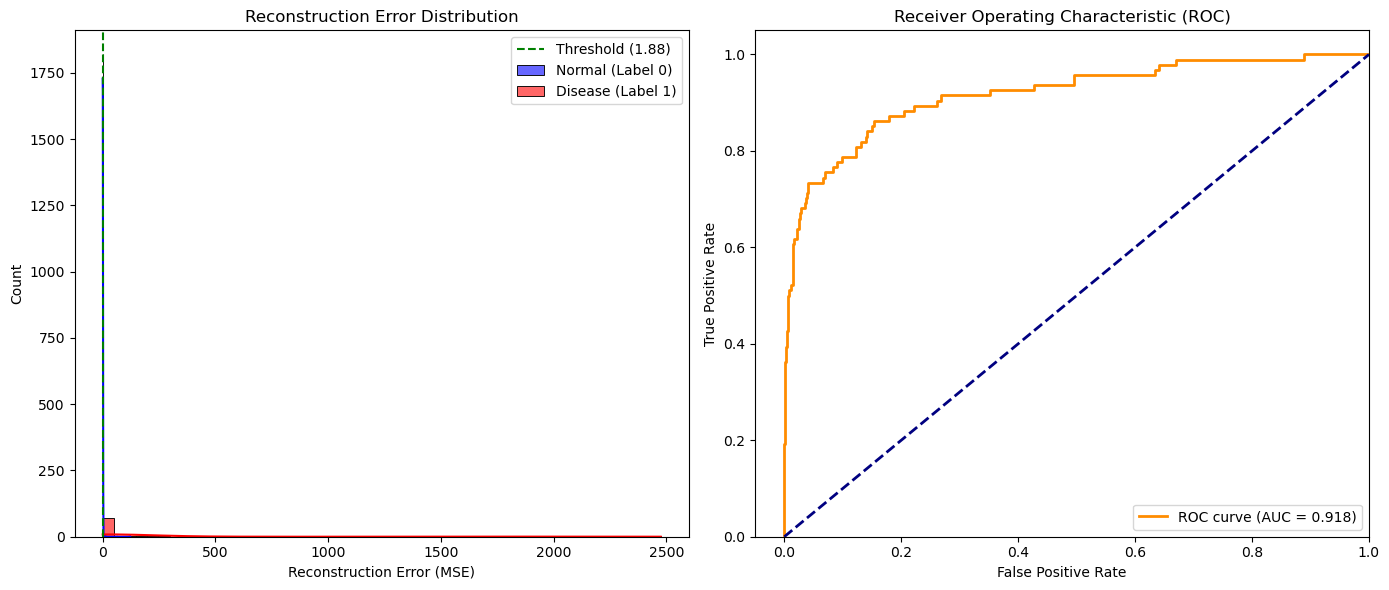

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 环境配置 (针对 M 芯片 Mac 优化)
# ==========================================
def get_device():
    if torch.backends.mps.is_available():
        print("✅ 检测到 M 芯片，启用 MPS (Metal) 加速")
        return torch.device("mps")
    elif torch.cuda.is_available():
        print("✅ 检测到 NVIDIA GPU，启用 CUDA 加速")
        return torch.device("cuda")
    else:
        print("⚠️ 未检测到 GPU，使用 CPU")
        return torch.device("cpu")

device = get_device()

# ==========================================
# 2. 数据准备与预处理
# ==========================================
# 读取数据
print("\nLoading data...")
train_df = pd.read_csv('./Thyroid/train-set.csv')
test_df = pd.read_csv('./Thyroid/test-set.csv')

# 数据转换
# 训练集：只包含特征，无标签（全是正常样本）
X_train = train_df.values.astype(np.float32)

# 测试集：分离特征和标签
X_test = test_df.drop('label', axis=1).values.astype(np.float32)
y_test = test_df['label'].values.astype(int) # 0: 正常, 1: 患病

# 标准化 (StandardScaler)
# 统计学注意：必须使用训练集的参数来缩放测试集，防止数据泄露
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 转换为 PyTorch Tensor 并移动到计算设备 (MPS/GPU/CPU)
train_tensor = torch.from_numpy(X_train_scaled).to(device)
test_tensor = torch.from_numpy(X_test_scaled).to(device)

# ==========================================
# 3. 模型定义: 自动编码器 (Autoencoder)
# ==========================================
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        # 编码器 (Encoder): 将 6 维压缩到 2 维潜在空间
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 4),
            nn.Tanh(),          # Tanh 激活函数处理负值较好的数据
            nn.Linear(4, 2),    # 瓶颈层 (Bottleneck)
            nn.Tanh()
        )
        # 解码器 (Decoder): 将 2 维还原回 6 维
        self.decoder = nn.Sequential(
            nn.Linear(2, 4),
            nn.Tanh(),
            nn.Linear(4, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# 初始化模型
input_dim = X_train.shape[1]
model = Autoencoder(input_dim).to(device)
criterion = nn.MSELoss()  # 损失函数：均方误差
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ==========================================
# 4. 模型训练
# ==========================================
print("\nStarting training...")
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=64, shuffle=True)
epochs = 50

model.train()
for epoch in range(epochs):
    total_loss = 0
    for batch in train_loader:
        inputs = batch[0]
        
        # 前向传播
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        
        # 反向传播
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}')

# ==========================================
# 5. 模型评估 (在测试集上)
# ==========================================
print("\nEvaluating...")
model.eval()
with torch.no_grad():
    # 获取测试集的重构结果
    reconstructions = model(test_tensor)
    
    # 计算每个样本的重构误差 (MSE)
    # 既然在 device 上计算，需要转回 CPU 进行 numpy 操作
    mse_loss = torch.mean((test_tensor - reconstructions)**2, dim=1).cpu().numpy()

# 计算 ROC 曲线和 AUC
fpr, tpr, thresholds = roc_curve(y_test, mse_loss)
roc_auc = auc(fpr, tpr)

# 利用 Precision-Recall 曲线寻找最佳阈值 (最大化 F1 Score)
precision, recall, pr_thresholds = precision_recall_curve(y_test, mse_loss)
f1_scores = 2 * recall * precision / (recall + precision + 1e-10)
best_f1_idx = np.argmax(f1_scores)
# 注意：pr_thresholds 长度比 precision/recall 少 1
if best_f1_idx < len(pr_thresholds):
    best_threshold = pr_thresholds[best_f1_idx]
else:
    best_threshold = pr_thresholds[-1]

# 根据最佳阈值生成预测标签
y_pred = (mse_loss > best_threshold).astype(int)

# ==========================================
# 6. 结果输出与可视化
# ==========================================
print("\n" + "="*30)
print(f"评估结果 Summary")
print("="*30)
print(f"AUC Score      : {roc_auc:.4f}")
print(f"Best Threshold : {best_threshold:.4f} (based on F1)")
print(f"Best F1 Score  : {f1_scores[best_f1_idx]:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Disease']))

# 绘图
plt.figure(figsize=(14, 6))

# 图1: 重构误差分布图 (直方图)
plt.subplot(1, 2, 1)
sns.histplot(mse_loss[y_test==0], bins=50, color='blue', label='Normal (Label 0)', kde=True, alpha=0.6)
sns.histplot(mse_loss[y_test==1], bins=50, color='red', label='Disease (Label 1)', kde=True, alpha=0.6)
plt.axvline(best_threshold, color='green', linestyle='--', label=f'Threshold ({best_threshold:.2f})')
plt.title('Reconstruction Error Distribution')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Count')
plt.legend()

# 图2: ROC 曲线
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")

plt.tight_layout()
plt.savefig('thyroid.png')
plt.show()